/tmp/ipykernel_3557727/639015212.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


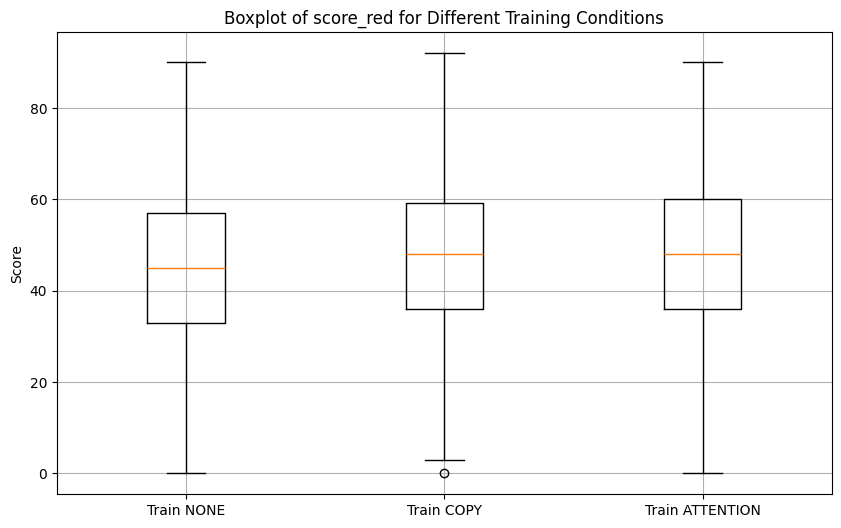

Two-sample t-test between NONE and COPY: t-statistic = -3.831, p-value = 0.000
Two-sample t-test between NONE and ATTENTION: t-statistic = -6.046, p-value = 0.000
Two-sample t-test between COPY and ATTENTION: t-statistic = -2.370, p-value = 0.018


In [1]:
"""
iteration,steps,env_steps,internal_ticks,score_red
1,79,79,600,81.0
2,68,68,600,105.0
3,72,72,600,93.0
4,70,70,600,105.0
5,80,80,600,87.0
"""

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

train_none = pd.read_csv('job_results/job_229746/PPO_2026-03-05_11-48-44/results.csv')
train_copy = pd.read_csv('job_results/job_229747/PPO_2026-03-05_11-48-44/results.csv')
train_attention = pd.read_csv('job_results/job_229748/PPO_2026-03-05_11-48-44/results.csv')

# Create boxplots for score_red
plt.figure(figsize=(10, 6))
plt.boxplot(
    [train_none['score_red'], train_copy['score_red'], train_attention['score_red']], 
    labels=['Train NONE', 'Train COPY', 'Train ATTENTION']) 
plt.title('Boxplot of score_red for Different Training Conditions')
plt.ylabel('Score')
plt.grid(True)
plt.show()

from scipy.stats import ttest_ind
t_stat, p_value = ttest_ind(train_none['score_red'], train_copy['score_red'])
print(f'Two-sample t-test between NONE and COPY: t-statistic = {t_stat:.3f}, p-value = {p_value:.3f}')

t_stat, p_value = ttest_ind(train_none['score_red'], train_attention['score_red'])
print(f'Two-sample t-test between NONE and ATTENTION: t-statistic = {t_stat:.3f}, p-value = {p_value:.3f}')

t_stat, p_value = ttest_ind(train_copy['score_red'], train_attention['score_red'])
print(f'Two-sample t-test between COPY and ATTENTION: t-statistic = {t_stat:.3f}, p-value = {p_value:.3f}')